<a href="https://colab.research.google.com/github/rajcyrus/capstone-project/blob/main/assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the dataset

In [1]:
# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("housing.csv")

# Display the first five rows
print("First Five Rows of the Dataset:")
print(df.head())

# Display the data types of each column
print("\nData Types of Columns:")
print(df.dtypes)

# Display the shape of the DataFrame
print("\nShape of the DataFrame:")
print(df.shape)

First Five Rows of the Dataset:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale

null value analysis

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("housing.csv")

# Count missing values
null_count = df.isnull().sum()

# Calculate percentage of missing values
null_percentage = (df.isnull().sum() / df.shape[0]) * 100

# Create a summary table
null_summary = pd.DataFrame({
    'Missing Values': null_count,
    'Percentage (%)': null_percentage
})

# Display columns with missing values
print("Missing Value Summary:")
print(null_summary[null_summary['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False))

# Columns with more than 20% missing values
high_null_columns = null_summary[null_summary['Percentage (%)'] > 20]

print("\nColumns with more than 20% missing values:")
print(high_null_columns)

# Fill numeric columns having less than 20% missing values with median
for col in df.columns:
    if (df[col].isnull().sum() > 0) and (df[col].isnull().sum() / df.shape[0] * 100 < 20):
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)

print("\nMissing values after median imputation:")
print(df.isnull().sum())

Missing Value Summary:
                Missing Values  Percentage (%)
Pool QC                   2917       99.556314
Misc Feature              2824       96.382253
Alley                     2732       93.242321
Fence                     2358       80.477816
Mas Vnr Type              1775       60.580205
Fireplace Qu              1422       48.532423
Lot Frontage               490       16.723549
Garage Qual                159        5.426621
Garage Cond                159        5.426621
Garage Yr Blt              159        5.426621
Garage Finish              159        5.426621
Garage Type                157        5.358362
Bsmt Exposure               83        2.832765
BsmtFin Type 2              81        2.764505
Bsmt Cond                   80        2.730375
Bsmt Qual                   80        2.730375
BsmtFin Type 1              80        2.730375
Mas Vnr Area                23        0.784983
Bsmt Full Bath               2        0.068259
Bsmt Half Bath               2       

/tmp/ipykernel_1929/4107006549.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


remove duplicate rows and compare missing value

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv("housing.csv")

# Calculate null percentages before removing duplicates
null_before = (df.isnull().sum() / df.shape[0]) * 100

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Remove duplicate rows
df_clean = df.drop_duplicates()

# Calculate how many rows were removed
rows_removed = len(df) - len(df_clean)

print("Rows removed:", rows_removed)

# Calculate null percentages after removing duplicates
null_after = (df_clean.isnull().sum() / df_clean.shape[0]) * 100

# Compare null percentages
comparison = pd.DataFrame({
    'Before (%)': null_before,
    'After (%)': null_after,
    'Change (%)': null_after - null_before
})

print("\nChange in Missing Value Percentages:")
print(comparison[comparison['Change (%)'] != 0])

# If no changes
if comparison['Change (%)'].abs().sum() == 0:
    print("\nNo column's null percentage changed after removing duplicates.")

Number of duplicate rows: 0
Rows removed: 0

Change in Missing Value Percentages:
Empty DataFrame
Columns: [Before (%), After (%), Change (%)]
Index: []

No column's null percentage changed after removing duplicates.


data type correction

In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv("housing.csv")

# Memory usage before conversion
memory_before = df.memory_usage(deep=True).sum()

print(f"Memory Usage Before Conversion: {memory_before / 1024:.2f} KB")

# -------------------------------------------------------
# Example 1: Convert a numeric column stored as object
# (Only if such a column exists)
# -------------------------------------------------------

if df['Garage Yr Blt'].dtype == 'object':
    df['Garage Yr Blt'] = pd.to_numeric(df['Garage Yr Blt'], errors='coerce')

# -------------------------------------------------------
# Example 2: Convert repetitive string columns to category
# -------------------------------------------------------

category_columns = [
    'MS Zoning',
    'Street',
    'Neighborhood',
    'House Style',
    'Exterior 1st'
]

for col in category_columns:
    df[col] = df[col].astype('category')

# Memory usage after conversion
memory_after = df.memory_usage(deep=True).sum()

print(f"Memory Usage After Conversion: {memory_after / 1024:.2f} KB")

print(f"Memory Saved: {(memory_before - memory_after)/1024:.2f} KB")

# Display updated data types
print("\nUpdated Data Types:")
print(df[category_columns].dtypes)

Memory Usage Before Conversion: 7081.35 KB
Memory Usage After Conversion: 6327.39 KB
Memory Saved: 753.96 KB

Updated Data Types:
MS Zoning       category
Street          category
Neighborhood    category
House Style     category
Exterior 1st    category
dtype: object


Descriptive statistics and skewness:

In [5]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("housing.csv")

# Select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Descriptive statistics
print("Descriptive Statistics:")
print(numeric_df.describe())

# Calculate skewness for each numeric column
skewness = numeric_df.skew()

# Create a DataFrame for better readability
skew_df = pd.DataFrame({
    'Skewness': skewness,
    'Absolute Skewness': skewness.abs()
}).sort_values(by='Absolute Skewness', ascending=False)

print("\nSkewness of Numeric Columns:")
print(skew_df)

# Identify the column with the highest absolute skewness
highest_skew_col = skew_df.index[0]
highest_skew_value = skew_df.iloc[0]['Skewness']

print("\nColumn with Highest Absolute Skewness:")
print(f"{highest_skew_col}: {highest_skew_value:.3f}")

Descriptive Statistics:
            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2907.000000   
mean       6.094881      5.563140  1971.356314     1984.266553    101.896801   
std        1.411026      1.111537    30.24

Outlier detection with IQR

In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv("housing.csv")

# Select two numeric columns for outlier detection
columns = ['SalePrice', 'Lot Area']

for col in columns:
    # Calculate Q1, Q3, and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate lower and upper bounds
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Print results
    print(f"\nColumn: {col}")
    print(f"Q1           : {Q1:.2f}")
    print(f"Q3           : {Q3:.2f}")
    print(f"IQR          : {IQR:.2f}")
    print(f"Lower Bound  : {lower_bound:.2f}")
    print(f"Upper Bound  : {upper_bound:.2f}")
    print(f"Outlier Count: {len(outliers)}")


Column: SalePrice
Q1           : 129500.00
Q3           : 213500.00
IQR          : 84000.00
Lower Bound  : 3500.00
Upper Bound  : 339500.00
Outlier Count: 137

Column: Lot Area
Q1           : 7440.25
Q3           : 11555.25
IQR          : 4115.00
Lower Bound  : 1267.75
Upper Bound  : 17727.75
Outlier Count: 127


Visualizations

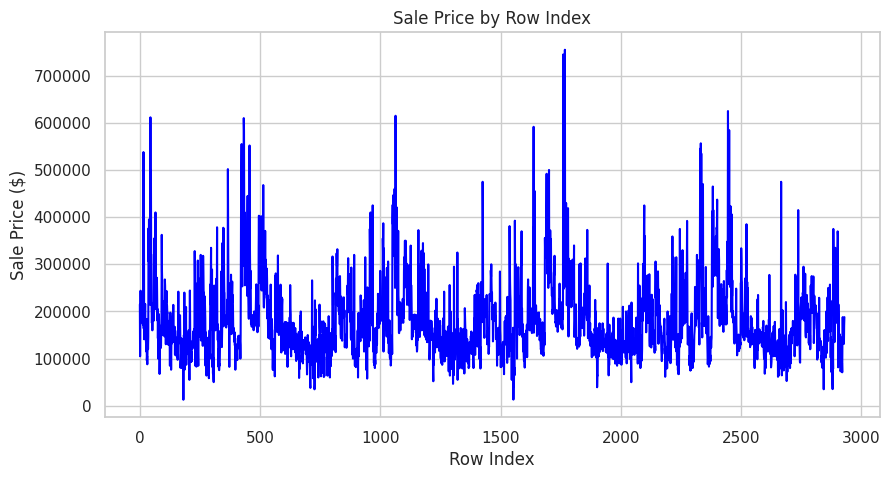

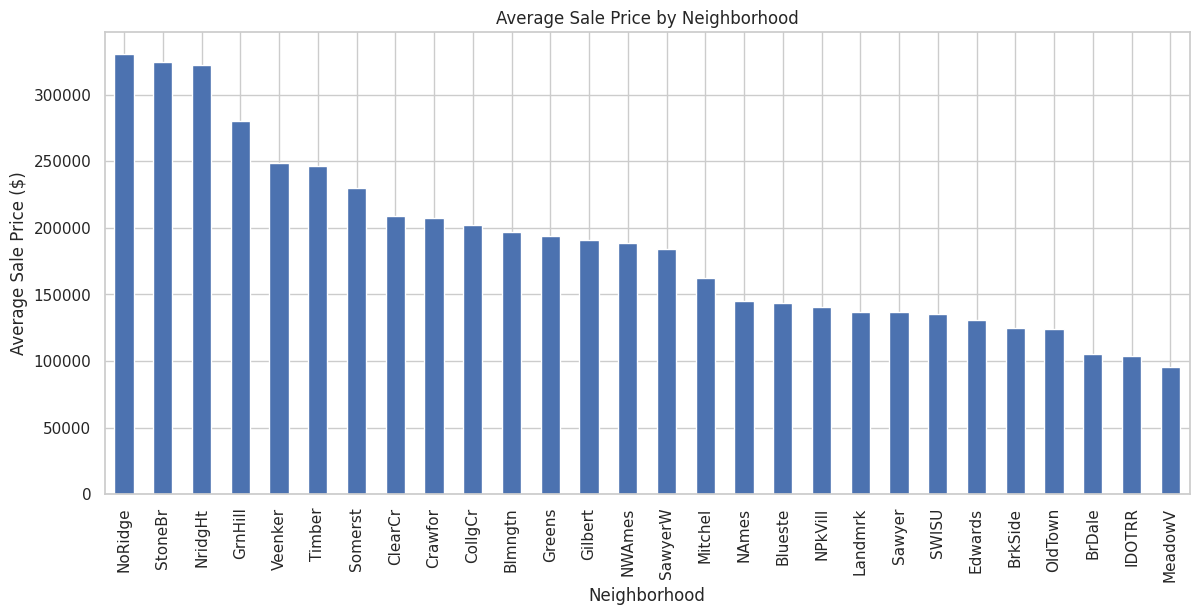

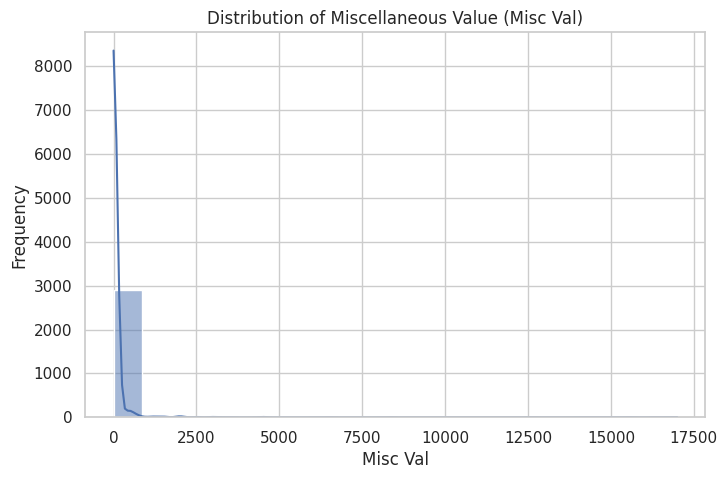

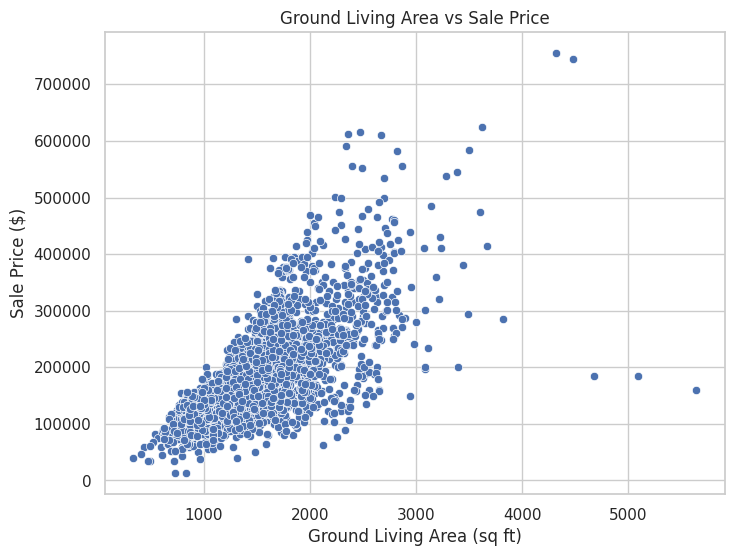

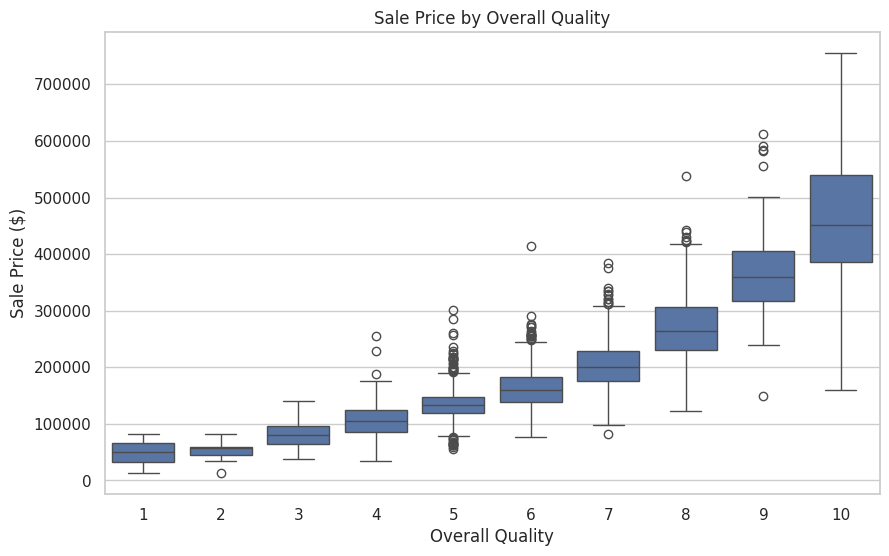

In [7]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("housing.csv")

# Set Seaborn style
sns.set(style="whitegrid")

# ==========================================================
# 1. Line Plot
# Numeric Variable: SalePrice
# ==========================================================

plt.figure(figsize=(10,5))
plt.plot(df.index, df['SalePrice'], color='blue')
plt.title("Sale Price by Row Index")
plt.xlabel("Row Index")
plt.ylabel("Sale Price ($)")
plt.show()

# ==========================================================
# 2. Bar Chart
# Mean SalePrice by Neighborhood
# ==========================================================

mean_price = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,6))
mean_price.plot(kind='bar')
plt.title("Average Sale Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Sale Price ($)")
plt.xticks(rotation=90)
plt.show()

# ==========================================================
# 3. Histogram
# Most Skewed Column: Misc Val
# ==========================================================

plt.figure(figsize=(8,5))
sns.histplot(df['Misc Val'], bins=20, kde=True)
plt.title("Distribution of Miscellaneous Value (Misc Val)")
plt.xlabel("Misc Val")
plt.ylabel("Frequency")
plt.show()

# ==========================================================
# 4. Scatter Plot
# Above Grade Living Area vs Sale Price
# ==========================================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Gr Liv Area',
    y='SalePrice'
)
plt.title("Ground Living Area vs Sale Price")
plt.xlabel("Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.show()

# ==========================================================
# 5. Box Plot
# SalePrice by Overall Quality
# ==========================================================

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='Overall Qual',
    y='SalePrice'
)
plt.title("Sale Price by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price ($)")
plt.show()

Correlation heat map

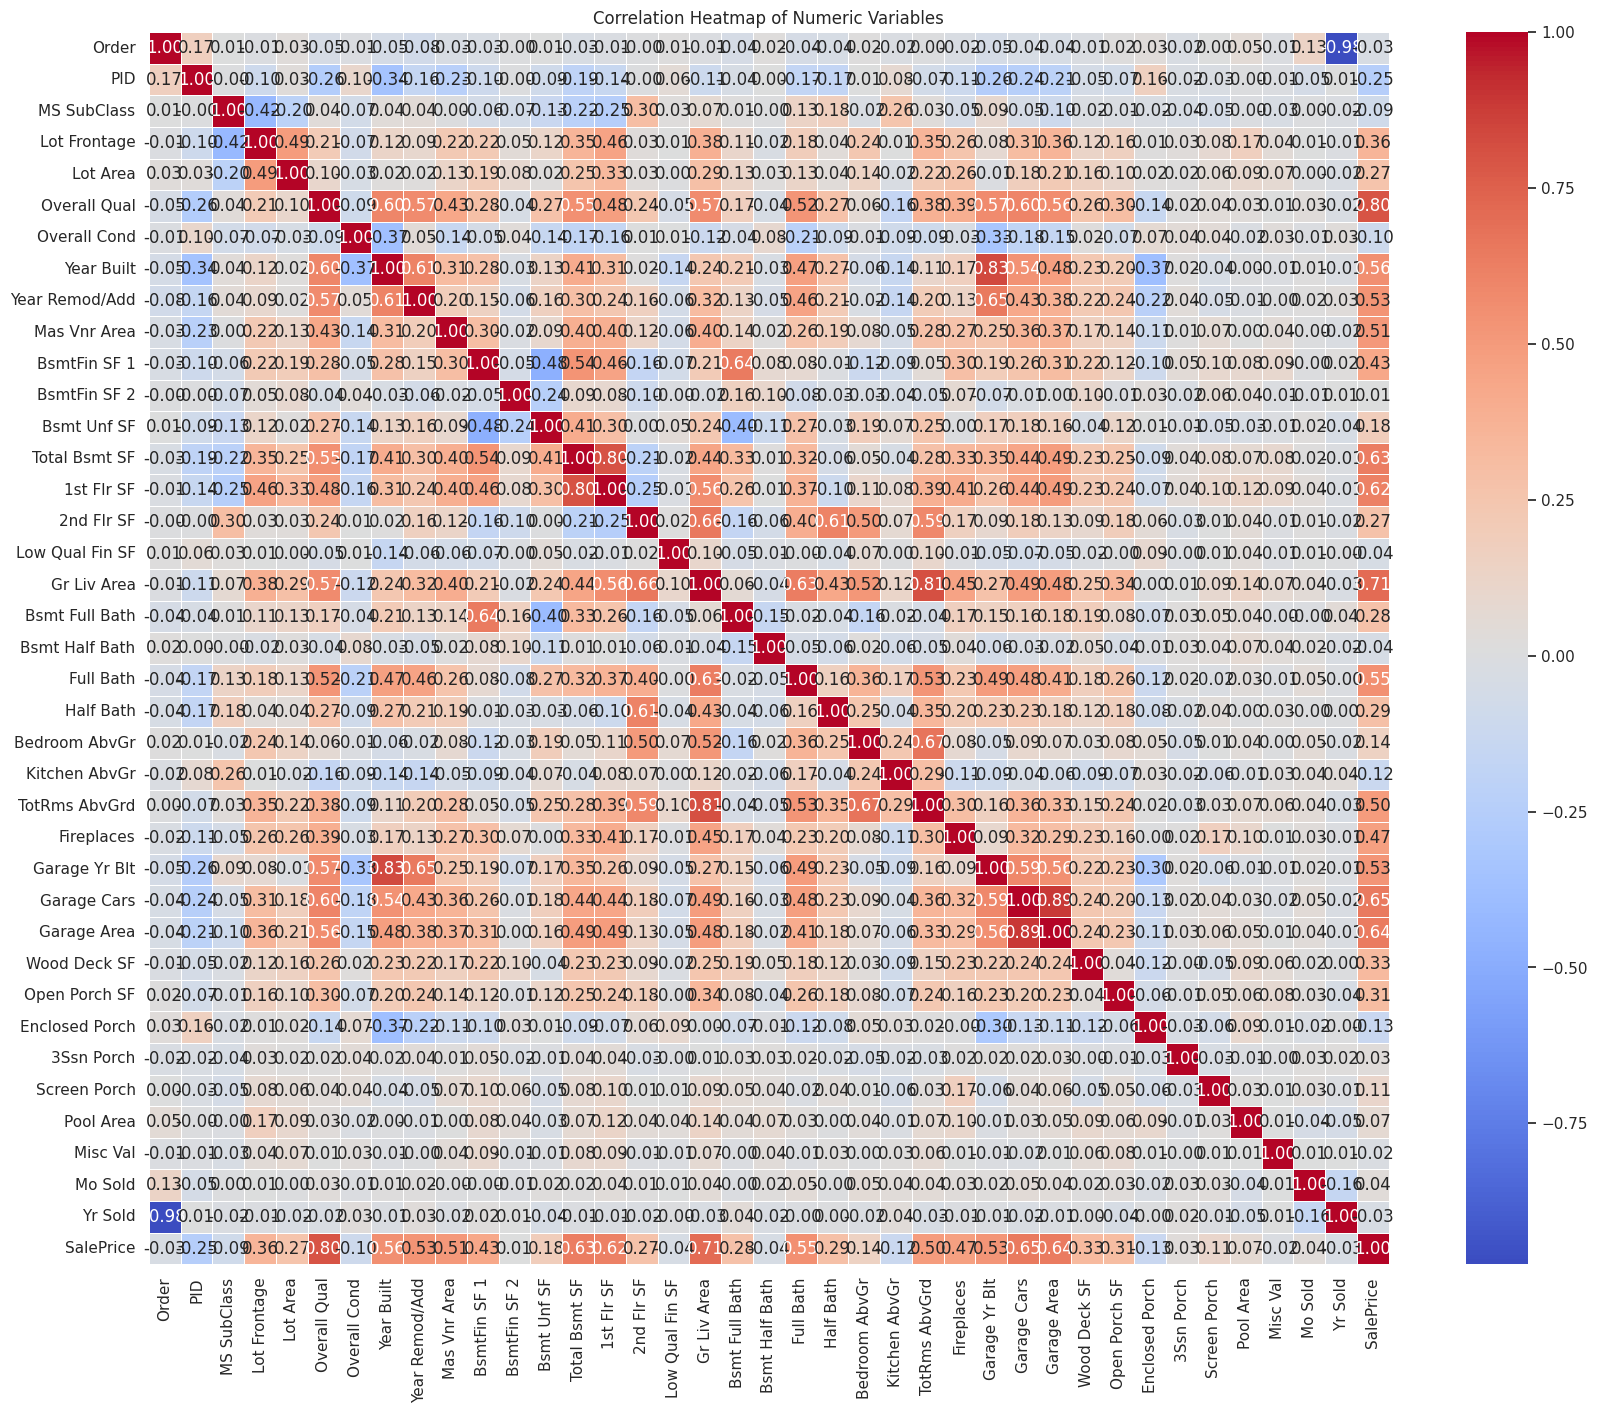

Highest Absolute Correlation:
Order and Yr Sold
Correlation = 0.976


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv("housing.csv")

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(20,16))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

# ----------------------------------------------------
# Find the pair with the highest absolute correlation
# (excluding self-correlation)
# ----------------------------------------------------

corr_abs = corr_matrix.abs()

# Ignore diagonal values
np.fill_diagonal(corr_abs.values, 0)

# Find maximum correlation pair
max_corr = corr_abs.unstack().idxmax()
max_value = corr_abs.unstack().max()

print("Highest Absolute Correlation:")
print(f"{max_corr[0]} and {max_corr[1]}")
print(f"Correlation = {max_value:.3f}")

Imputation strategy comparison

In [9]:
import pandas as pd

# Load dataset
df = pd.read_csv("housing.csv")

# Two most skewed numeric columns
columns = ['Misc Val', 'Pool Area']

print("Mean and Median Before Imputation\n")

for col in columns:
    mean_value = df[col].mean()
    median_value = df[col].median()

    print(f"{col}")
    print(f"Mean   : {mean_value:.2f}")
    print(f"Median : {median_value:.2f}")
    print("-" * 35)

# ---------------------------------------------------
# Median Imputation
# ---------------------------------------------------

for col in columns:
    df[col] = df[col].fillna(df[col].median())

print("\nRemaining Missing Values After Imputation:")

for col in columns:
    print(f"{col}: {df[col].isnull().sum()}")

Mean and Median Before Imputation

Misc Val
Mean   : 50.64
Median : 0.00
-----------------------------------
Pool Area
Mean   : 2.24
Median : 0.00
-----------------------------------

Remaining Missing Values After Imputation:
Misc Val: 0
Pool Area: 0


Spearman rank correlation

In [10]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("housing.csv")

# Select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Pearson Correlation Matrix
pearson_corr = numeric_df.corr(method='pearson')

# Spearman Correlation Matrix
spearman_corr = numeric_df.corr(method='spearman')

print("Pearson Correlation Matrix")
print(pearson_corr)

print("\nSpearman Correlation Matrix")
print(spearman_corr)

# ---------------------------------------------------
# Calculate absolute difference
# ---------------------------------------------------

difference = (spearman_corr - pearson_corr).abs()

# Remove duplicate pairs and diagonal
pairs = []

for i in range(len(difference.columns)):
    for j in range(i+1, len(difference.columns)):
        pairs.append({
            "Variable 1": difference.columns[i],
            "Variable 2": difference.columns[j],
            "Pearson": pearson_corr.iloc[i, j],
            "Spearman": spearman_corr.iloc[i, j],
            "Absolute Difference": difference.iloc[i, j]
        })

diff_table = pd.DataFrame(pairs)

diff_table = diff_table.sort_values(
    by="Absolute Difference",
    ascending=False
)

print("\nTop 3 Column Pairs with Largest Difference")
print(diff_table.head(3))

Pearson Correlation Matrix
                    Order       PID  MS SubClass  Lot Frontage  Lot Area  \
Order            1.000000  0.173593     0.011797     -0.007034  0.031354   
PID              0.173593  1.000000    -0.001281     -0.096918  0.034868   
MS SubClass      0.011797 -0.001281     1.000000     -0.420135 -0.204613   
Lot Frontage    -0.007034 -0.096918    -0.420135      1.000000  0.491313   
Lot Area         0.031354  0.034868    -0.204613      0.491313  1.000000   
Overall Qual    -0.048500 -0.263147     0.039419      0.212042  0.097188   
Overall Cond    -0.011054  0.104451    -0.067349     -0.074448 -0.034759   
Year Built      -0.052319 -0.343388     0.036579      0.121562  0.023258   
Year Remod/Add  -0.075566 -0.157111     0.043397      0.091712  0.021682   
Mas Vnr Area    -0.030907 -0.229283     0.002730      0.222407  0.126830   
BsmtFin SF 1    -0.032321 -0.098375    -0.060075      0.215583  0.191555   
BsmtFin SF 2    -0.002773 -0.001145    -0.070946      0.04599

Grouped aggregation

In [11]:
import pandas as pd

# Load the dataset
df = pd.read_csv("housing.csv")

# Group by Neighborhood and compute statistics for SalePrice
group_stats = df.groupby('Neighborhood')['SalePrice'].agg(['mean', 'std', 'count'])

# Sort by mean sale price (highest first)
group_stats = group_stats.sort_values(by='mean', ascending=False)

print("Grouped Aggregation (Neighborhood vs SalePrice)")
print(group_stats)

# --------------------------------------------------------
# Highest mean
# --------------------------------------------------------
highest_mean_group = group_stats['mean'].idxmax()
highest_mean = group_stats['mean'].max()

# Lowest mean
lowest_mean_group = group_stats['mean'].idxmin()
lowest_mean = group_stats['mean'].min()

# Highest standard deviation
highest_std_group = group_stats['std'].idxmax()
highest_std = group_stats['std'].max()

# Ratio of highest mean to lowest mean
ratio = highest_mean / lowest_mean

print("\nSummary")
print(f"Highest Mean SalePrice      : {highest_mean_group} ({highest_mean:.2f})")
print(f"Highest Std Deviation       : {highest_std_group} ({highest_std:.2f})")
print(f"Lowest Mean SalePrice       : {lowest_mean_group} ({lowest_mean:.2f})")
print(f"Highest Mean / Lowest Mean  : {ratio:.2f}")

Grouped Aggregation (Neighborhood vs SalePrice)
                       mean            std  count
Neighborhood                                     
NoRidge       330319.126761  101444.662927     71
StoneBr       324229.196078  119273.020694     51
NridgHt       322018.265060   95932.354274    166
GrnHill       280000.000000   70710.678119      2
Veenker       248314.583333   65474.949540     24
Timber        246599.541667   69326.471547     72
Somerst       229707.324176   57437.392588    182
ClearCr       208662.090909   51280.213463     44
Crawfor       207550.834951   65230.183286    103
CollgCr       201803.434457   54187.843749    267
Blmngtn       196661.678571   29317.511457     28
Greens        193531.250000   21998.554133      8
Gilbert       190646.575758   33050.029652    165
NWAmes        188406.908397   37687.782531    131
SawyerW       184070.184000   48995.503318    125
Mitchel       162226.631579   41356.861245    114
NAmes         145097.349887   31882.707229    443
Bl

saving dataset

In [12]:
import pandas as pd

# Load the original dataset
df = pd.read_csv("housing.csv")

# =====================================================
# Perform all cleaning steps here
# (Missing value handling, duplicate removal,
# data type corrections, etc.)
# =====================================================

# Example: Remove duplicates
df = df.drop_duplicates()

# Example: Fill missing values in numeric columns
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    if df[col].isnull().sum() > 0:
        null_percentage = (df[col].isnull().sum() / len(df)) * 100
        if null_percentage < 20:
            df[col] = df[col].fillna(df[col].median())

# Example: Convert selected object columns to category
category_columns = [
    'MS Zoning',
    'Street',
    'Neighborhood',
    'House Style',
    'Exterior 1st'
]

for col in category_columns:
    df[col] = df[col].astype('category')

# =====================================================
# Save the cleaned dataset
# =====================================================

df.to_csv("cleaned_data.csv", index=False)

print("The cleaned dataset has been saved successfully as 'cleaned_data.csv'.")

The cleaned dataset has been saved successfully as 'cleaned_data.csv'.
